# **SECTION 0: SETUP & IMPORTS**

In [1]:
!pip install xgboost --quiet
!pip install networkx --quiet

import time
import gc
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from google.colab import drive

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete!")

Setup complete!


# **SECTION 1: MOUNT GOOGLE DRIVE & LOAD DATA**

In [2]:
# Mount Google Drive
drive.mount('/content/drive')

# Set paths (UPDATE THIS PATH TO MATCH YOUR FOLDER STRUCTURE)
DATA_DIR = "/content/drive/MyDrive/aml_project/data"
TRANS_PATH = f"{DATA_DIR}/HI-Small_Trans.csv"
ACCOUNTS_PATH = f"{DATA_DIR}/HI-Small_accounts.csv"
PATTERNS_PATH = f"{DATA_DIR}/HI-Small_Patterns.txt"

# Verify files exist
print("\nVerifying files...")
for name, path in [
    ("Transactions", TRANS_PATH),
    ("Accounts", ACCOUNTS_PATH),
    ("Patterns", PATTERNS_PATH)
]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  {name}: {size_mb:.1f} MB")
    else:
        print(f"  {name}: NOT FOUND at {path}")

# Load data with optimized dtypes
dtype_map = {
    "From Bank": "category",
    "To Bank": "category",
    "Receiving Currency": "category",
    "Payment Currency": "category",
    "Payment Format": "category",
    "Amount Received": "float32",
    "Amount Paid": "float32",
    "Is Laundering": "int8",
}

df = pd.read_csv(TRANS_PATH, dtype=dtype_map)
print(f"\nLoaded {len(df):,} transactions")
print(f"   Shape: {df.shape}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# Check illicit rate
illicit_rate = df["Is Laundering"].mean()
print(f"Illicit rate: {illicit_rate:.4%}")
print(f"   Positive: {df['Is Laundering'].sum():,} / {len(df):,}")

df.head()

Mounted at /content/drive

Verifying files...
  Transactions: 453.6 MB
  Accounts: 32.5 MB
  Patterns: 0.3 MB

Loaded 5,078,345 transactions
   Shape: (5078345, 11)
   Memory: 1.00 GB
Illicit rate: 0.1019%
   Positive: 5,177 / 5,078,345


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,010,8000EBD30,010,8000EBD30,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0
1,2022/09/01 00:20,03208,8000F4580,001,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0
2,2022/09/01 00:00,03209,8000F4670,03209,8000F4670,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0
3,2022/09/01 00:02,012,8000F5030,012,8000F5030,2806.969971,US Dollar,2806.969971,US Dollar,Reinvestment,0
4,2022/09/01 00:06,010,8000F5200,010,8000F5200,36682.968750,US Dollar,36682.968750,US Dollar,Reinvestment,0


# **SECTION 2: COLUMN DEFINITIONS & CLEANING**

In [3]:
# Column names
COL_TIME = "Timestamp"
COL_FROM_BANK = "From Bank"
COL_FROM_ACCT = "Account"
COL_TO_BANK = "To Bank"
COL_TO_ACCT = "Account.1"
COL_AMT_RECV = "Amount Received"
COL_CUR_RECV = "Receiving Currency"
COL_AMT_PAID = "Amount Paid"
COL_CUR_PAID = "Payment Currency"
COL_FORMAT = "Payment Format"
COL_LABEL = "Is Laundering"

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# Parse timestamps
df[COL_TIME] = pd.to_datetime(df[COL_TIME], errors='coerce')
df = df.dropna(subset=[COL_TIME])
df = df.sort_values(COL_TIME).reset_index(drop=True)

# Create unique account IDs
df["src_id"] = df[COL_FROM_BANK].astype(str) + "_" + df[COL_FROM_ACCT].astype(str)
df["dst_id"] = df[COL_TO_BANK].astype(str) + "_" + df[COL_TO_ACCT].astype(str)

# Clean amounts
for col in [COL_AMT_RECV, COL_AMT_PAID]:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=[COL_AMT_RECV, COL_AMT_PAID])

print(f"Cleaned shape: {df.shape}")

Dropped 9 duplicate rows
Cleaned shape: (5078336, 13)


# **SECTION 3: BASE FEATURES**

In [4]:
# Amount features
df["log_amount_paid"] = np.log1p(df[COL_AMT_PAID]).astype("float32")
df["log_amount_received"] = np.log1p(df[COL_AMT_RECV]).astype("float32")
df["amount_discrepancy"] = (df[COL_AMT_PAID] - df[COL_AMT_RECV]).astype("float32")

# Comparison features (convert to string to avoid categorical errors)
df["currency_mismatch"] = (df[COL_CUR_PAID] != df[COL_CUR_RECV]).astype("int8")
df["cross_bank"] = (df[COL_FROM_BANK].astype(str) != df[COL_TO_BANK].astype(str)).astype("int8")
df["self_loop"] = (df["src_id"] == df["dst_id"]).astype("int8")

# Temporal features
df["hour_of_day"] = df[COL_TIME].dt.hour.astype("int8")
df["day_of_week"] = df[COL_TIME].dt.dayofweek.astype("int8")
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

# One-hot encode
df = pd.get_dummies(df, columns=[COL_FORMAT], prefix="fmt", dtype="int8")

top_currencies = df[COL_CUR_PAID].value_counts().head(8).index
df["currency_grp"] = np.where(df[COL_CUR_PAID].isin(top_currencies), df[COL_CUR_PAID], "OTHER")
df = pd.get_dummies(df, columns=["currency_grp"], prefix="cur", dtype="int8")

gc.collect()
print(f"Base features complete: {df.shape}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Base features complete: (5078336, 37)
   Memory: 1.54 GB


# **SECTION 4: CHRONOLOGICAL SPLIT**

In [5]:
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

n = len(df)
train_end = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

train_raw = df.iloc[:train_end].reset_index(drop=True)
val_raw = df.iloc[train_end:val_end].reset_index(drop=True)
test_raw = df.iloc[val_end:].reset_index(drop=True)

print("Chronological Split:")
for name, part in [("Train", train_raw), ("Val", val_raw), ("Test", test_raw)]:
    n_rows = len(part)
    illicit = part[COL_LABEL].mean()
    print(f"  {name}: {n_rows:,} rows, illicit={illicit:.4%}")

Chronological Split:
  Train: 3,554,835 rows, illicit=0.0803%
  Val: 761,750 rows, illicit=0.0998%
  Test: 761,751 rows, illicit=0.2049%


# **SECTION 5: GRAPH FEATURES**

In [6]:
def account_level_stats(history_df):
    out_deg = history_df.groupby("src_id").size().rename("out_degree")
    in_deg = history_df.groupby("dst_id").size().rename("in_degree")
    fan_out = history_df.groupby("src_id")["dst_id"].nunique().rename("fan_out_unique")
    fan_in = history_df.groupby("dst_id")["src_id"].nunique().rename("fan_in_unique")

    out_amt = history_df.groupby("src_id")[COL_AMT_PAID].agg(["sum", "mean", "std"])
    out_amt.columns = ["out_amount_sum", "out_amount_mean", "out_amount_std"]

    in_amt = history_df.groupby("dst_id")[COL_AMT_RECV].agg(["sum", "mean", "std"])
    in_amt.columns = ["in_amount_sum", "in_amount_mean", "in_amount_std"]

    stats = pd.concat([out_deg, in_deg, fan_out, fan_in, out_amt, in_amt], axis=1).fillna(0)
    for c in stats.columns:
        stats[c] = stats[c].astype("float32")
    stats["in_out_ratio"] = (stats["in_degree"] + 1) / (stats["out_degree"] + 1)
    return stats

def build_adjacency(history_df):
    edges = history_df[["src_id", "dst_id"]].drop_duplicates()
    adj = {}
    for s, d in zip(edges["src_id"].values, edges["dst_id"].values):
        adj.setdefault(s, set()).add(d)
    n_nodes = len(set(edges["src_id"]).union(edges["dst_id"]))
    n_edges = len(edges)
    del edges
    return adj, n_nodes, n_edges

def bounded_cycle_search(adj, out_degree, max_cycle_len=5, degree_cap=25, time_budget_sec=180):
    t0 = time.time()
    cycle_nodes = set()
    low_degree_nodes = [n for n, d in out_degree.items() if d <= degree_cap]

    for start in low_degree_nodes:
        if time.time() - t0 > time_budget_sec:
            print(f"  Timeout at {time_budget_sec}s")
            break
        stack = [(start, [start])]
        while stack:
            node, path = stack.pop()
            if len(path) > max_cycle_len:
                continue
            for nxt in adj.get(node, ()):
                if out_degree.get(nxt, 0) > degree_cap and nxt != start:
                    continue
                if nxt == start and len(path) >= 2:
                    cycle_nodes.update(path)
                elif nxt not in path and len(path) < max_cycle_len:
                    stack.append((nxt, path + [nxt]))
    return cycle_nodes

def cycle_and_hub_sets(history_df, max_cycle_len=5, degree_cap=25, time_budget_sec=180, hub_threshold=10):
    adj, n_nodes, n_edges = build_adjacency(history_df)
    out_degree = {n: len(v) for n, v in adj.items()}
    print(f"    Graph: {n_nodes:,} nodes, {n_edges:,} edges")

    t0 = time.time()
    cycle_nodes = bounded_cycle_search(adj, out_degree, max_cycle_len, degree_cap, time_budget_sec)
    print(f"    Cycles: {len(cycle_nodes):,} accounts in {time.time()-t0:.1f}s")

    in_degree = history_df.groupby("dst_id").size().to_dict()
    fan_out_hubs = {n for n, d in out_degree.items() if d >= hub_threshold}
    fan_in_hubs = {n for n, d in in_degree.items() if d >= hub_threshold}
    print(f"    Fan-out hubs: {len(fan_out_hubs):,}, Fan-in hubs: {len(fan_in_hubs):,}")

    del adj, out_degree, in_degree
    gc.collect()
    return cycle_nodes, fan_out_hubs, fan_in_hubs

def velocity_features_causal(full_df, window_hours=24):
    window = f"{window_hours}h"
    d = full_df[["src_id", COL_TIME, COL_AMT_PAID]].copy()
    d = d.sort_values(COL_TIME).reset_index(drop=True)
    d["_key"] = range(len(d))

    d_idx = d.set_index(COL_TIME)
    roll = d_idx.groupby("src_id")[COL_AMT_PAID].rolling(window).agg(["count", "sum"]).reset_index()
    del d_idx

    roll = roll.sort_values(COL_TIME).reset_index(drop=True)
    roll["_key"] = d["_key"].values
    roll = roll.rename(columns={"count": "src_velocity_count_24h", "sum": "src_velocity_amount_24h"})
    del d

    full_df = full_df.sort_values(COL_TIME).reset_index(drop=True)
    full_df["src_velocity_count_24h"] = roll["src_velocity_count_24h"].values.astype("float32")
    full_df["src_velocity_amount_24h"] = roll["src_velocity_amount_24h"].values.astype("float32")

    del roll
    gc.collect()
    return full_df

def apply_graph_features(target_df, history_df, tag):
    print(f"  [{tag}] Scoring {len(target_df):,} rows using {len(history_df):,} history rows")

    stats = account_level_stats(history_df)
    src_stats = stats.add_prefix("src_")
    dst_stats = stats.add_prefix("dst_")

    out = target_df.merge(src_stats, left_on="src_id", right_index=True, how="left")
    out = out.merge(dst_stats, left_on="dst_id", right_index=True, how="left")
    del stats, src_stats, dst_stats

    stat_cols = [c for c in out.columns if (c.startswith("src_") or c.startswith("dst_"))
                 and c not in ("src_id", "dst_id")]
    out[stat_cols] = out[stat_cols].fillna(0)

    cycle_nodes, fan_out_hubs, fan_in_hubs = cycle_and_hub_sets(history_df)

    out["src_in_cycle"] = out["src_id"].isin(cycle_nodes).astype("int8")
    out["dst_in_cycle"] = out["dst_id"].isin(cycle_nodes).astype("int8")
    out["src_is_fan_out_hub"] = out["src_id"].isin(fan_out_hubs).astype("int8")
    out["dst_is_fan_in_hub"] = out["dst_id"].isin(fan_in_hubs).astype("int8")
    del cycle_nodes, fan_out_hubs, fan_in_hubs

    hist_mean = history_df.groupby("src_id")[COL_AMT_PAID].mean()
    hist_std = history_df.groupby("src_id")[COL_AMT_PAID].std().fillna(0)

    out["_hist_mean"] = out["src_id"].map(hist_mean).fillna(out[COL_AMT_PAID].mean()).astype("float32")
    out["_hist_std"] = out["src_id"].map(hist_std).fillna(0).astype("float32")

    out["amount_zscore_vs_src_history"] = np.where(
        out["_hist_std"] > 0,
        (out[COL_AMT_PAID] - out["_hist_mean"]) / out["_hist_std"],
        0.0
    ).astype("float32")

    out = out.drop(columns=["_hist_mean", "_hist_std"])
    gc.collect()
    return out

# Compute velocity
full = pd.concat([train_raw, val_raw, test_raw], ignore_index=True)
full = velocity_features_causal(full)

n_tr, n_va = len(train_raw), len(val_raw)
train_raw = full.iloc[:n_tr].reset_index(drop=True)
val_raw = full.iloc[n_tr:n_tr + n_va].reset_index(drop=True)
test_raw = full.iloc[n_tr + n_va:].reset_index(drop=True)
del full

# Apply graph features per split
print("\n Applying graph features...")
train = apply_graph_features(train_raw, train_raw, "train")
val = apply_graph_features(val_raw, train_raw, "val")
train_val_history = pd.concat([train_raw, val_raw], ignore_index=True)
test = apply_graph_features(test_raw, train_val_history, "test")

# Clean up
del train_raw, val_raw, test_raw, train_val_history
gc.collect()

print(f"\nGraph features complete!")
print(f"   Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")


 Applying graph features...
  [train] Scoring 3,554,835 rows using 3,554,835 history rows
    Graph: 513,292 nodes, 955,901 edges
    Cycles: 3,268 accounts in 13.7s
    Fan-out hubs: 3,742, Fan-in hubs: 162,120
  [val] Scoring 761,750 rows using 3,554,835 history rows
    Graph: 513,292 nodes, 955,901 edges
    Cycles: 3,268 accounts in 12.5s
    Fan-out hubs: 3,742, Fan-in hubs: 162,120
  [test] Scoring 761,751 rows using 4,316,585 history rows
    Graph: 514,167 nodes, 987,880 edges
    Cycles: 4,704 accounts in 14.8s
    Fan-out hubs: 5,066, Fan-in hubs: 172,361

Graph features complete!
   Train: (3554835, 66), Val: (761750, 66), Test: (761751, 66)


# **SECTION 6: FEATURE MATRIX**

In [7]:
NON_FEATURE_COLS = {
    COL_TIME, COL_FROM_BANK, COL_FROM_ACCT, COL_TO_BANK, COL_TO_ACCT,
    COL_CUR_RECV, COL_CUR_PAID, "src_id", "dst_id", COL_LABEL,
}

BASELINE_FEATURES = [
    "log_amount_paid", "log_amount_received", "amount_discrepancy",
    "currency_mismatch", "cross_bank", "self_loop",
    "hour_of_day", "day_of_week", "is_weekend",
]

def get_feature_cols(d):
    cols = [c for c in d.columns if c not in NON_FEATURE_COLS]
    non_numeric = [c for c in cols if not pd.api.types.is_numeric_dtype(d[c])]
    if non_numeric:
        cols = [c for c in cols if c not in non_numeric]
    return cols

def to_xy(d, cols):
    X = d[cols].fillna(0).astype(np.float32)
    y = d[COL_LABEL].astype(int)
    return X, y

full_cols = get_feature_cols(train)
base_cols = [c for c in BASELINE_FEATURES if c in full_cols]

print(f"Baseline features: {len(base_cols)}, Full features: {len(full_cols)}")

X_train_full, y_train = to_xy(train, full_cols)
X_val_full, y_val = to_xy(val, full_cols)
X_train_base, _ = to_xy(train, base_cols)
X_val_base, _ = to_xy(val, base_cols)

Baseline features: 9, Full features: 56


# **SECTION 7: MODEL TRAINING**

In [8]:
def train_xgboost(X_train, y_train, X_val, y_val, tag):
    n_pos = int(y_train.sum())
    n_neg = int(len(y_train) - n_pos)
    scale_pos_weight = n_neg / max(n_pos, 1)
    print(f"[{tag}] n_pos={n_pos}, n_neg={n_neg}, scale={scale_pos_weight:.1f}")

    model = XGBClassifier(
        max_depth=7,
        learning_rate=0.08,
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        early_stopping_rounds=30,
        verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    print(f"[{tag}] Trained, best_iteration={model.best_iteration}")
    return model

print("Training BASELINE model...")
baseline_model = train_xgboost(X_train_base, y_train, X_val_base, y_val, "baseline")

print("\nTraining FULL model...")
full_model = train_xgboost(X_train_full, y_train, X_val_full, y_val, "full")

Training BASELINE model...
[baseline] n_pos=2856, n_neg=3551979, scale=1243.7
[baseline] Trained, best_iteration=64

Training FULL model...
[full] n_pos=2856, n_neg=3551979, scale=1243.7
[full] Trained, best_iteration=155


# **SECTION 8: EVALUATION**

In [9]:
def best_threshold_by_f1(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec + 1e-12), 0)
    if len(thr) == 0:
        return 0.5, 0.0
    best_idx = np.argmax(f1[:-1])
    return float(thr[best_idx]), float(f1[best_idx])

def evaluate_model(model, X, y, tag):
    y_prob = model.predict_proba(X)[:, 1]
    ap = average_precision_score(y, y_prob)

    y_pred_05 = (y_prob >= 0.5).astype(int)
    p05 = precision_score(y, y_pred_05, zero_division=0)
    r05 = recall_score(y, y_pred_05, zero_division=0)
    f05 = f1_score(y, y_pred_05, zero_division=0)

    best_thr, _ = best_threshold_by_f1(y, y_prob)
    y_pred_t = (y_prob >= best_thr).astype(int)
    pt = precision_score(y, y_pred_t, zero_division=0)
    rt = recall_score(y, y_pred_t, zero_division=0)
    ft = f1_score(y, y_pred_t, zero_division=0)

    cm = confusion_matrix(y, y_pred_t)

    print(f"[{tag}] PR-AUC={ap:.4f}")
    print(f"  @0.5:            P={p05:.4f} R={r05:.4f} F1={f05:.4f}")
    print(f"  @tuned={best_thr:.3f}:  P={pt:.4f} R={rt:.4f} F1={ft:.4f}")
    print(f"  CM: TN={cm[0,0]:,} FP={cm[0,1]:,} FN={cm[1,0]:,} TP={cm[1,1]:,}")

    return {
        "tag": tag, "pr_auc": ap,
        "threshold": best_thr,
        "precision": pt, "recall": rt, "f1": ft,
        "cm": cm, "y_prob": y_prob
    }

X_test_base, y_test = to_xy(test, base_cols)
X_test_full, _ = to_xy(test, full_cols)

r_base = evaluate_model(baseline_model, X_test_base, y_test, "baseline")
print()
r_full = evaluate_model(full_model, X_test_full, y_test, "full")

lift = r_full["f1"] - r_base["f1"]
lift_pct = (lift / max(r_base["f1"], 1e-9)) * 100
print(f"\nGraph feature F1 lift: {lift:+.4f} ({lift_pct:+.1f}%)")

# Comparison table
comparison_table = pd.DataFrame([
    {"Model": "Baseline", "PR-AUC": r_base["pr_auc"], "F1": r_base["f1"],
     "Precision": r_base["precision"], "Recall": r_base["recall"]},
    {"Model": "Full Graph", "PR-AUC": r_full["pr_auc"], "F1": r_full["f1"],
     "Precision": r_full["precision"], "Recall": r_full["recall"]}
])
print("\nComparison:")
print(comparison_table.to_string(index=False))
comparison_table.to_csv("comparison_table.csv", index=False)

[baseline] PR-AUC=0.0133
  @0.5:            P=0.0055 R=0.7636 F1=0.0110
  @tuned=0.904:  P=0.0338 R=0.0423 F1=0.0376
  CM: TN=758,305 FP=1,885 FN=1,495 TP=66

[full] PR-AUC=0.1180
  @0.5:            P=0.0477 R=0.7034 F1=0.0894
  @tuned=0.956:  P=0.1457 R=0.2454 F1=0.1828
  CM: TN=757,944 FP=2,246 FN=1,178 TP=383

Graph feature F1 lift: +0.1452 (+386.4%)

Comparison:
     Model   PR-AUC       F1  Precision   Recall
  Baseline 0.013259 0.037585   0.033829 0.042281
Full Graph 0.118035 0.182816   0.145683 0.245356


# **SECTION 9: PLOTS**

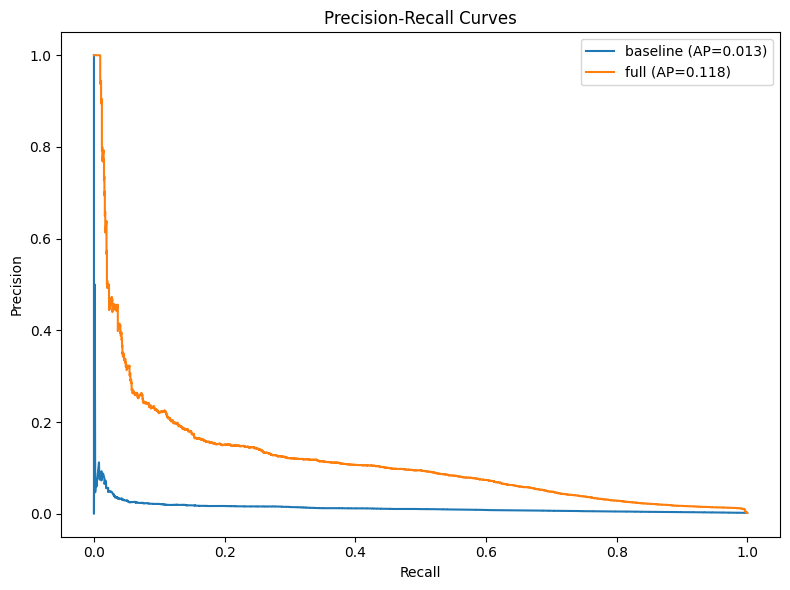

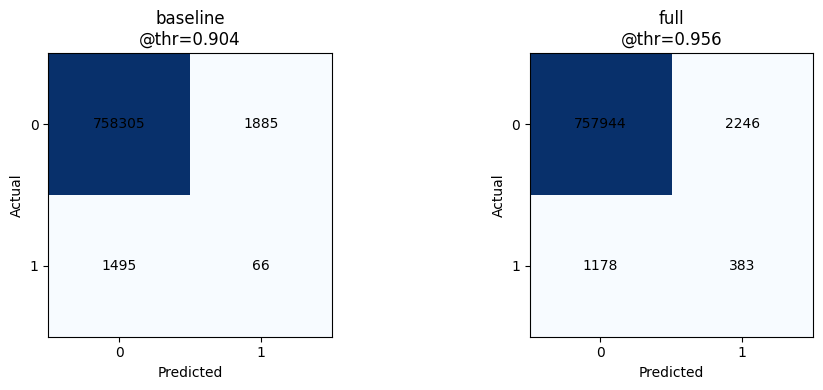

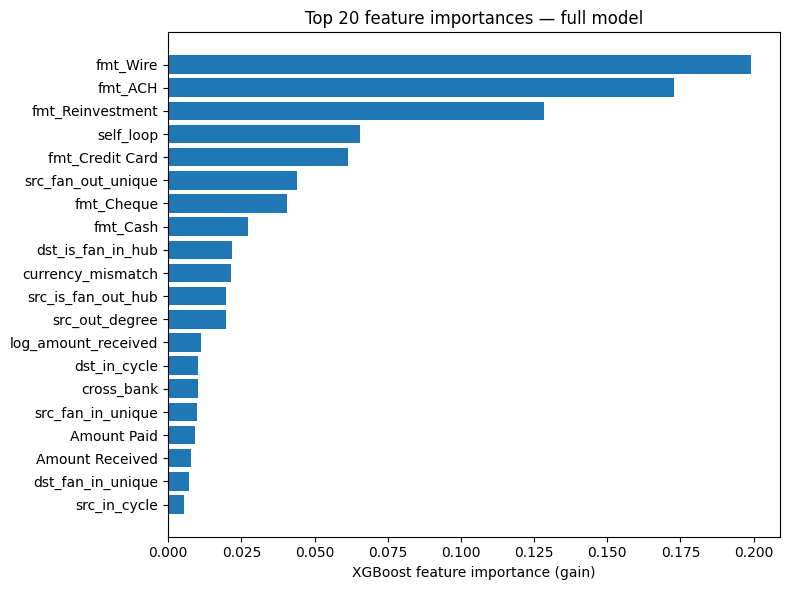

In [10]:
# PR Curve
plt.figure(figsize=(8, 6))
for r in (r_base, r_full):
    prec, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    plt.plot(rec, prec, label=f"{r['tag']} (AP={r['pr_auc']:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, r in zip(axes, (r_base, r_full)):
    cm = r["cm"]
    ax.imshow(cm, cmap="Blues")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_title(f"{r['tag']}\n@thr={r['threshold']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

# Feature importance
importances = full_model.feature_importances_
order = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(8, 6))
plt.barh(np.array(full_cols)[order][::-1], importances[order][::-1])
plt.xlabel("XGBoost feature importance (gain)")
plt.title("Top 20 feature importances — full model")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# **SECTION 10: SUSPICIOUS ACCOUNTS**

In [11]:
test_scored = test.copy()
test_scored["risk_score"] = r_full["y_prob"]

acct_view = pd.concat([
    test_scored[["src_id", "risk_score", COL_AMT_PAID, COL_LABEL]]
        .rename(columns={"src_id": "account_id", COL_AMT_PAID: "amount"}),
    test_scored[["dst_id", "risk_score", COL_AMT_RECV, COL_LABEL]]
        .rename(columns={"dst_id": "account_id", COL_AMT_RECV: "amount"}),
])

suspicious_accounts = acct_view.groupby("account_id").agg(
    max_risk_score=("risk_score", "max"),
    avg_risk_score=("risk_score", "mean"),
    n_flagged_txns=("risk_score", lambda s: int((s >= 0.5).sum())),
    total_amount_involved=("amount", "sum"),
    n_true_illicit_txns=(COL_LABEL, "sum"),
).reset_index().sort_values("max_risk_score", ascending=False)

suspicious_accounts.head(100).to_csv("suspicious_accounts.csv", index=False)
print("Saved: suspicious_accounts.csv")

print("\nTOP 10 SUSPICIOUS ACCOUNTS:")
print(suspicious_accounts.head(10).to_string(index=False))

Saved: suspicious_accounts.csv

TOP 10 SUSPICIOUS ACCOUNTS:
       account_id  max_risk_score  avg_risk_score  n_flagged_txns  total_amount_involved  n_true_illicit_txns
0048309_811C599A0        0.999288        0.864747              18           7.914269e+05                   18
   0222_811B83280        0.999288        0.392652               9           4.842181e+05                    9
0150240_812D22980        0.998944        0.579917               8           3.494383e+05                    8
0148350_811FFF630        0.998293        0.466090               6           3.716818e+05                    5
0148350_812D0C3C0        0.998293        0.499370               6           1.934330e+05                    4
   0119_811C597B0        0.998163        0.596062               9           2.856691e+07                    9
0050528_812D0C600        0.997978        0.746183               6           2.148099e+05                    5
    023_80016A6F0        0.997356        0.297772           

# **SECTION 11: GROUND TRUTH VALIDATION**

In [12]:
try:
    pattern_accounts = set()
    pattern_type = {}
    current_type = None

    with open(PATTERNS_PATH) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if "BEGIN LAUNDERING ATTEMPT" in line.upper():
                current_type = line.split("-")[-1].strip() if "-" in line else "UNKNOWN"
                continue
            if "END LAUNDERING ATTEMPT" in line.upper():
                current_type = None
                continue
            if current_type is None:
                continue
            parts = line.split(",")
            if len(parts) < 5:
                continue
            from_bank, from_acct = parts[1].strip(), parts[2].strip()
            to_bank, to_acct = parts[3].strip(), parts[4].strip()
            src = f"{from_bank}_{from_acct}"
            dst = f"{to_bank}_{to_acct}"
            pattern_accounts.add(src)
            pattern_accounts.add(dst)
            pattern_type[src] = current_type
            pattern_type[dst] = current_type

    print(f"Parsed {len(pattern_accounts):,} pattern accounts")

    test_accounts = set(test["src_id"]) | set(test["dst_id"])
    pattern_in_test = pattern_accounts & test_accounts
    print(f"Pattern accounts in test: {len(pattern_in_test):,}")

    print("\nTop-K matches:")
    for k in [100, 500, 1000, 2000, 5000]:
        top_k = set(suspicious_accounts.head(k)["account_id"])
        matches = top_k & pattern_in_test
        precision = len(matches) / k * 100 if k > 0 else 0
        recall = len(matches) / max(len(pattern_in_test), 1) * 100
        print(f"  Top {k:>5}: {len(matches):>4} matches  (Precision: {precision:.1f}%)")

    top_matches = suspicious_accounts[
        suspicious_accounts["account_id"].isin(pattern_in_test)
    ].head(5).copy()
    top_matches["pattern_type"] = top_matches["account_id"].map(pattern_type)
    print("\nCase studies:")
    print(top_matches[["account_id", "max_risk_score", "n_flagged_txns", "pattern_type"]].to_string(index=False))

except FileNotFoundError:
    print("Patterns file not found - skipping validation")

Parsed 3,170 pattern accounts
Pattern accounts in test: 2,661

Top-K matches:
  Top   100:   36 matches  (Precision: 36.0%)
  Top   500:   99 matches  (Precision: 19.8%)
  Top  1000:  162 matches  (Precision: 16.2%)
  Top  2000:  263 matches  (Precision: 13.2%)
  Top  5000:  497 matches  (Precision: 9.9%)

Case studies:
       account_id  max_risk_score  n_flagged_txns pattern_type
0048309_811C599A0        0.999288              18           In
   0222_811B83280        0.999288               9           In
0150240_812D22980        0.998944               8           In
0148350_811FFF630        0.998293               6    BIPARTITE
0148350_812D0C3C0        0.998293               6    BIPARTITE


# **SECTION 12: FINAL SUMMARY**

In [14]:
print("\n" + "=" * 60)
print("AML PIPELINE COMPLETE")
print("=" * 60)

print(f"\nModel Performance:")
print(f"  Baseline PR-AUC:  {r_base['pr_auc']:.4f}")
print(f"  Full Model PR-AUC: {r_full['pr_auc']:.4f}")
print(f"  Improvement:       {lift_pct:+.1f}%")
print(f"  F1 Score:          {r_full['f1']:.4f}")
print(f"  Precision:         {r_full['precision']:.1%}")
print(f"  Recall:            {r_full['recall']:.1%}")

print("\nOutput Files:")
for f in ["suspicious_accounts.csv", "comparison_table.csv", "pr_curve.png", "confusion_matrices.png", "feature_importance.png"]:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f} ({size_kb:.1f} KB)")

print("\n" + "=" * 60)


AML PIPELINE COMPLETE

Model Performance:
  Baseline PR-AUC:  0.0133
  Full Model PR-AUC: 0.1180
  Improvement:       +386.4%
  F1 Score:          0.1828
  Precision:         14.6%
  Recall:            24.5%

Output Files:
  suspicious_accounts.csv (5.1 KB)
  comparison_table.csv (0.2 KB)
  pr_curve.png (49.6 KB)
  confusion_matrices.png (29.8 KB)
  feature_importance.png (80.4 KB)

